# Trader Performance vs. Bitcoin Market Sentiment

Exploratory notebook version of `src/analysis.py`. Run cells top to bottom.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('../data')
pd.set_option('display.max_columns', None)

## Load & merge data

In [2]:
trades = pd.read_csv(DATA_DIR / 'historical_data.csv')
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['Timestamp IST'].dt.date
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [3]:
fg = pd.read_csv(DATA_DIR / 'fear_greed_index.csv')
fg['date'] = pd.to_datetime(fg['date']).dt.date
fg = fg[['date', 'value', 'classification']].rename(columns={'value': 'fg_value', 'classification': 'sentiment'})
fg.head()

,date,fg_value,sentiment
0,2018-02-01,30,Fear
1,2018-02-02,15,Extreme Fear
2,2018-02-03,40,Fear
3,2018-02-04,24,Extreme Fear
4,2018-02-05,11,Extreme Fear


In [4]:
merged = trades.merge(fg, on='date', how='inner')
merged['is_closed_trade'] = merged['Closed PnL'] != 0
merged['is_win'] = merged['Closed PnL'] > 0
print(f'{len(merged):,} of {len(trades):,} trade rows matched to a sentiment day')
merged.head()

211,218 of 211,224 trade rows matched to a sentiment day


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,fg_value,sentiment,is_closed_trade,is_win
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80,Extreme Greed,False,False
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80,Extreme Greed,False,False
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80,Extreme Greed,False,False
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80,Extreme Greed,False,False
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80,Extreme Greed,False,False


## Performance by sentiment bucket

In [5]:
SENTIMENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

agg = merged.groupby('sentiment').agg(
    trades=('Closed PnL', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    median_pnl=('Closed PnL', 'median'),
    avg_size_usd=('Size USD', 'mean'),
    total_volume_usd=('Size USD', 'sum'),
    avg_fee=('Fee', 'mean'),
).reindex(SENTIMENT_ORDER)

closed = merged[merged['is_closed_trade']]
agg['win_rate_pct'] = closed.groupby('sentiment')['is_win'].mean() * 100
agg.round(2)

,trades,total_pnl,avg_pnl,median_pnl,avg_size_usd,total_volume_usd,avg_fee,win_rate_pct
sentiment,,,,,,,,
Extreme Fear,21400,739110.25,34.54,0.0,5349.73,1.144843e+08,1.12,76.22
Fear,61837,3357155.44,54.29,0.0,7816.11,4.833248e+08,1.50,87.29
Neutral,37686,1292920.68,34.31,0.0,4782.73,1.802421e+08,1.04,82.39
Greed,50303,2150129.27,42.74,0.0,5736.88,2.885825e+08,1.25,76.89
Extreme Greed,39992,2715171.31,67.89,0.0,3112.25,1.244652e+08,0.68,89.17


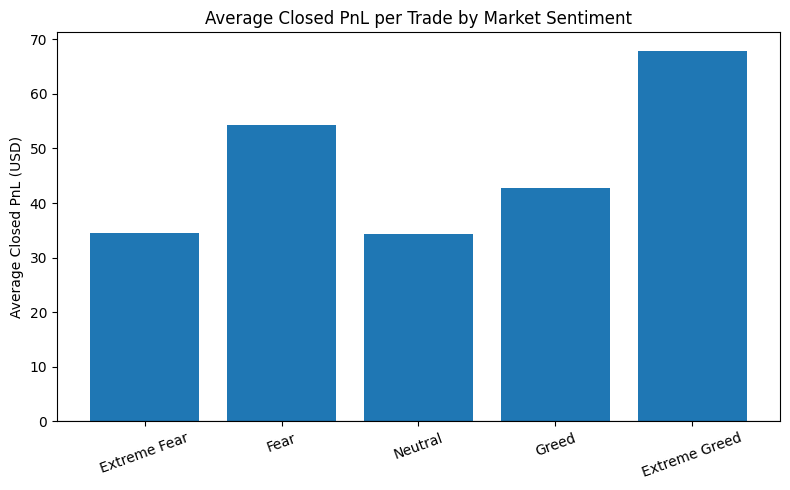

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(agg.index, agg['avg_pnl'])
ax.set_title('Average Closed PnL per Trade by Market Sentiment')
ax.set_ylabel('Average Closed PnL (USD)')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

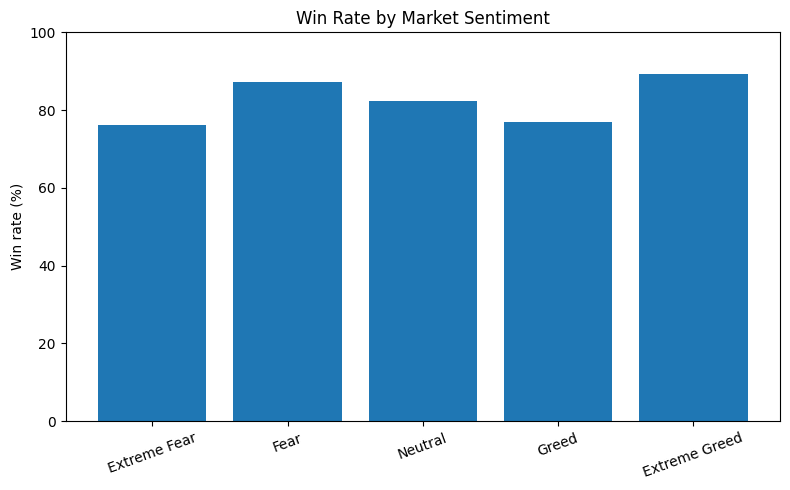

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(agg.index, agg['win_rate_pct'])
ax.set_title('Win Rate by Market Sentiment')
ax.set_ylabel('Win rate (%)')
ax.set_ylim(0, 100)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Is the pattern driven by a few accounts?

Check per-account average PnL split by sentiment — if the U-shape holds broadly across accounts (not just 1-2 whales), it's a more reliable signal.

In [8]:
pivot = merged.pivot_table(index='Account', columns='sentiment', values='Closed PnL', aggfunc='mean').reindex(columns=SENTIMENT_ORDER)
pivot.round(2).head(10)

sentiment,Extreme Fear,Fear,Neutral,Greed,Extreme Greed
Account,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,1247.69,626.19,298.46,482.09,-42.63
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,-24.91,-0.63,-16.57,10.21,43.22
0x271b280974205ca63b716753467d5a371de622ab,20.96,16.13,-31.78,-185.22,358.63
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,-44.71,9.59,6.21,10.50,14.44
0x2c229d22b100a7beb69122eed721cee9b24011dd,101.92,10.44,41.67,79.35,61.50
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-216.61,-1.82,-37.24,-34.63,192.50
0x39cef799f8b69da1995852eea189df24eb5cae3c,-45.67,37.18,40.27,168.12,125.27
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,5.82,53.88,4009.58,163.07,178.98
0x420ab45e0bd8863569a5efbb9c05d91f40624641,155.10,1016.82,1547.78,177.69,37.22


## Daily time series vs. raw index value

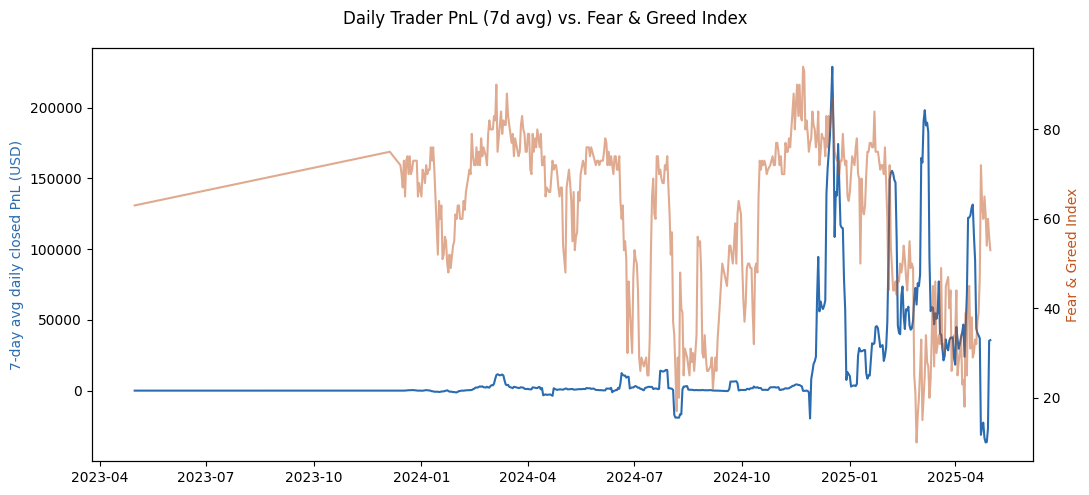

Pearson correlation (daily total PnL vs FG value): -0.0826


In [9]:
daily = merged.groupby('date').agg(pnl=('Closed PnL', 'sum'), fg_value=('fg_value', 'mean')).reset_index().sort_values('date')

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(daily['date'], daily['pnl'].rolling(7, min_periods=1).mean(), color='#2b6cb0', label='7d avg daily PnL')
ax1.set_ylabel('7-day avg daily closed PnL (USD)', color='#2b6cb0')
ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['fg_value'], color='#c05621', alpha=0.5, label='Fear & Greed Index')
ax2.set_ylabel('Fear & Greed Index', color='#c05621')
fig.suptitle('Daily Trader PnL (7d avg) vs. Fear & Greed Index')
fig.tight_layout()
plt.show()

corr = daily['pnl'].corr(daily['fg_value'])
print(f'Pearson correlation (daily total PnL vs FG value): {corr:.4f}')

## Takeaways

- Relationship between sentiment and PnL is **U-shaped**: strongest avg PnL and win rate at Extreme Greed and Fear, weaker in Neutral/Greed.
- Fear days have the highest trade count and volume — traders are most active, not least, when the market is nervous.
- Daily linear correlation between PnL and the raw index value is weak (~-0.08), so a **regime/bucket** signal is more informative than the continuous index score.
- See `../README.md` for the full write-up and strategy implications.